### <font color='blue'>Experiments with Gaussian generative models</font>

This notebook contains code that takes the parameters of a Gaussian generative model for two-dimensional data and does the following:
* It generates a few points from the model
* It plots the decision regions as well as the points

Begin with some standard includes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

This next function, `generate_data`, generates `n` points from a Gaussian generative model whose parameters are:
* `pi`: a vector of class weights
* `mu`: mean of each class (one row for each mean)
* `sigma`: covariance matrix of each class

In particular, if there are `k` classes, then `pi` is an array of size `k`, `mu` is an array of size `(k,2)` (since the data is two-dimensional) and `sigma` is an array of size `(k,2,2)`.

In [2]:
def generate_data(pi, mu, sigma, n):
    k = pi.shape[0] # classes
    x = np.zeros((n,2)) # the data
    # First select the label for each point
    y = np.random.choice(k, n, p=pi) # each point's label
    # Now generate the x values given the labels
    for i in range(0,n):
        c = y[i]
        x[i,:] = np.random.multivariate_normal(mu[c], sigma[c])
    return x, y # return (n,2) data / n labels randomly generated

The function `predict_on_grid` applies the generative model (`pi`, `mu`, `sigma`) to make predictions on every point of a grid. The parameter `grid` is an array of size `(gn, 2)`, where each row specifies a particular two-dimensional point on the grid.

In [3]:
def predict_on_grid(pi,mu,sigma,grid):
    k = pi.shape[0] # classes
    gn = grid.shape[0]
    Z = np.zeros(gn)
    score = np.zeros((gn,k))
    for label in range(0,k):
        rv = multivariate_normal(mean=mu[label], cov=sigma[label])
        for i in range(gn):
            score[i,label] = np.log(pi[label]) + rv.logpdf(grid[i,:])
    Z = np.argmax(score, axis=1)
    return Z

Function `show_boundary` draws the decision boundary for model (`pi`, `mu`, `sigma`) as well as plotting the points `x` (with labels `y`).

It works as follows:
* First it determines a bounding box for points `x`. This box is `[x0min, x0max] x [x1min, x1max]`.
* Then it puts a fine grid, of side length `delta`, on this bounding box.
* It uses the Gaussian generative model (`pi`, `mu`, `sigma`) to predict a label for every point on the grid.
* It then uses these predictions to color the grid

In [4]:
def show_boundary(pi,mu,sigma,x,y):
    n = y.shape[0] # number of points
    delta = 0.05
    x0min = min(x[:,0]) - 1
    x0max = max(x[:,0]) + 1   
    x1min = min(x[:,1]) - 1
    x1max = max(x[:,1]) + 1
    xx, yy = np.meshgrid(np.arange(x0min, x0max, delta), np.arange(x1min, x1max, delta))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_on_grid(pi,mu,sigma,grid)
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap=plt.cm.tab20c, vmin=-2, vmax=2)

    # Plot also the training points
    for i in range(0,n):
        c = y[i]
        plt.plot(x[i,0], x[i,1], 'o', color=cols[c], markersize=2)
    
    plt.xlim(x0min, x0max)
    plt.ylim(x1min, x1max)
    plt.axis('equal')
    plt.show()

Finally, let's call these functions.

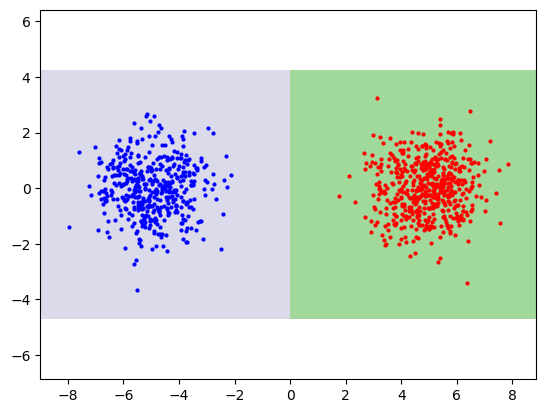

In [5]:
# Number of classes
k = 2 
#
# Class weights
pi = np.zeros(k)
pi[0] = 0.5
pi[1] = 0.5
#
# Class means
mu = np.zeros((k,2))
mu[0,] = [5,0]
mu[1,] = [-5,0]
#
# Covariance matrices
sigma = np.zeros((k,2,2))
sigma[0,] = [[1,0],[0,1]]
sigma[1,] = [[1,0],[0,1]]
#
# Select a color for each class
cols = ['red', 'blue']
#
# Generate 1000 points
x,y = generate_data(pi,mu,sigma,1000)
#
# Show boundary (and points)
show_boundary(pi,mu,sigma,x,y)

## Example 1: Linear boundary that is not parallel to the coordinate axes

To create a linear boundary that is not parallel to the coordinate axes, we'll use the same means but with non-identity covariance matrices that have the same eigenvalues but different eigenvectors.

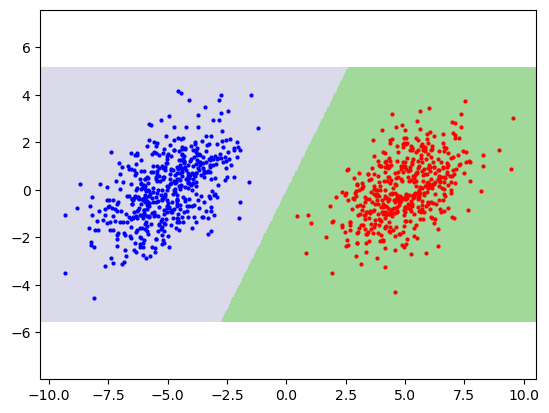

In [6]:
# Number of classes
k = 2 
#
# Class weights
pi = np.zeros(k)
pi[0] = 0.5
pi[1] = 0.5
#
# Class means (same as before)
mu = np.zeros((k,2))
mu[0,] = [5,0]
mu[1,] = [-5,0]
#
# Covariance matrices - modifying to create a rotated linear boundary
sigma = np.zeros((k,2,2))
# For a linear boundary that's not parallel to axes, use similar but rotated covariances
sigma[0,] = [[2, 1], [1, 2]]  # Positive correlation
sigma[1,] = [[2, 1], [1, 2]]  # Same covariance for both classes
#
# Select a color for each class
cols = ['red', 'blue']
#
# Generate 1000 points
x,y = generate_data(pi,mu,sigma,1000)
#
# Show boundary (and points)
show_boundary(pi,mu,sigma,x,y)

## Example 2: Spherical boundary

To create a spherical boundary, we'll use different variances for the two classes. When one class has a larger variance than the other, their boundary becomes spherical.

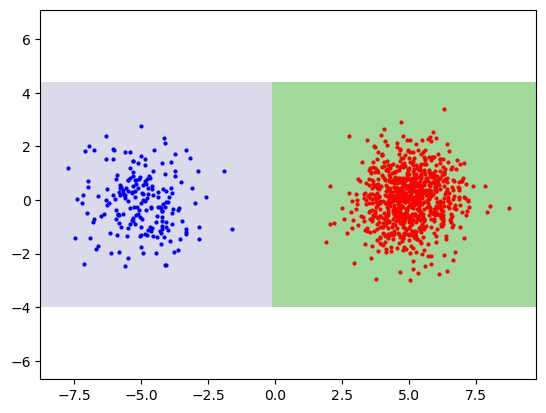

In [10]:
# Number of classes
k = 2 
#
# Class weights
pi = np.zeros(k)
pi[0] = 0.8
pi[1] = 0.2
#
# Class means (same as before)
mu = np.zeros((k,2))
mu[0,] = [5,0]
mu[1,] = [-5,0]
#
# Covariance matrices - modifying to create a spherical boundary
sigma = np.zeros((k,2,2))
# For a spherical boundary, use different scales of identity matrices
sigma[0,] = [[1, 0], [0, 1]]  
sigma[1,] = [[1, 0], [0, 1]]  
#
# Select a color for each class
cols = ['red', 'blue']
#
# Generate 1000 points
x,y = generate_data(pi,mu,sigma,1000)
#
# Show boundary (and points)
show_boundary(pi,mu,sigma,x,y)

## Example 3: Elliptical boundary

To create an elliptical boundary, we'll use different covariance matrices with different orientations for the two classes.

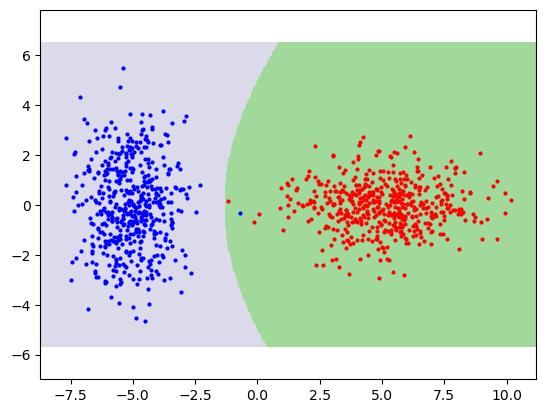

In [12]:
# Number of classes
k = 2 
#
# Class weights
pi = np.zeros(k)
pi[0] = 0.5
pi[1] = 0.5
#
# Class means (same as before)
mu = np.zeros((k,2))
mu[0,] = [5,0]
mu[1,] = [-5,0]
#
# Covariance matrices - modifying to create an elliptical boundary
sigma = np.zeros((k,2,2))
# For an elliptical boundary, use different covariances with different orientations
sigma[0,] = [[3, 0], [0, 1]]  # Stretched horizontally
sigma[1,] = [[1, 0], [0, 3]]  # Stretched in a diagonal direction
#
# Select a color for each class
cols = ['red', 'blue']
#
# Generate 1000 points
x,y = generate_data(pi,mu,sigma,1000)
#
# Show boundary (and points)
show_boundary(pi,mu,sigma,x,y)

## Bonus: Hyperbolic boundary

To create a hyperbolic boundary, we'll use covariance matrices with different orientations and opposite correlations.